In [1]:
import pandas as pd

load dataframe with engineered features

In [4]:
df_features = pd.read_csv(
    '../data/df_features.csv',
    dtype={'Invoice': 'string'},
    parse_dates=['invoice_datetime']
)
df_features

,Invoice,customer_id,invoice_datetime,invoice_total_amount,min_unit_price,max_unit_price,avg_unit_price,total_quantity,unique_item_count,is_cancelled,...,customer_dow_thu_rate,customer_dow_fri_rate,customer_dow_sat_rate,customer_dow_sun_rate,customer_tod_morning_rate,customer_tod_afternoon_rate,customer_tod_evening_rate,customer_tod_night_rate,customer_total_unique_products,customer_avg_days_between_orders
0,489434,13085.0,2009-12-01 07:45:00,505.30,1.25,6.95,4.081250,166,8,False,...,0.400000,0.300000,0.0,0.000000,0.400000,0.600000,0.000000,0.0,51,58.100000
1,489435,13085.0,2009-12-01 07:46:00,145.80,1.65,3.75,2.625000,60,4,False,...,0.400000,0.300000,0.0,0.000000,0.400000,0.600000,0.000000,0.0,51,58.100000
2,489436,13078.0,2009-12-01 09:06:00,630.33,1.25,8.50,3.730526,193,19,False,...,0.210526,0.147368,0.0,0.063158,0.294737,0.652632,0.052632,0.0,154,7.757895
3,489437,15362.0,2009-12-01 09:08:00,310.75,0.65,9.95,3.628261,145,23,False,...,0.000000,0.500000,0.0,0.000000,1.000000,0.000000,0.000000,0.0,38,145.000000
4,489438,18102.0,2009-12-01 09:24:00,2286.24,0.98,6.40,2.591176,826,17,False,...,0.261438,0.163399,0.0,0.019608,0.418301,0.470588,0.111111,0.0,384,5.089655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40500,C581484,16446.0,2011-12-09 09:27:00,-168469.60,2.08,2.08,2.080000,-80995,1,True,...,0.000000,0.500000,0.0,0.000000,0.750000,0.250000,0.000000,0.0,4,107.500000
40501,C581490,14397.0,2011-12-09 09:57:00,-32.53,0.83,1.95,1.390000,-23,2,True,...,0.173913,0.130435,0.0,0.130435,0.478261,0.478261,0.043478,0.0,18,9.217391
40502,C581499,15498.0,2011-12-09 10:28:00,-224.69,224.69,224.69,224.690000,-1,1,True,...,0.200000,0.309091,0.0,0.036364,0.400000,0.581818,0.018182,0.0,599,13.127273
40503,C581568,15311.0,2011-12-09 11:57:00,-54.75,10.95,10.95,10.950000,-5,1,True,...,0.140741,0.200000,0.0,0.044444,0.181481,0.814815,0.003704,0.0,870,2.743494


In [51]:
df_features.invoice_total_amount.duplicated().sum()

np.int64(14279)

TODO: explanation about scaling for PCA

In [28]:
from sklearn.preprocessing import StandardScaler

X = df_features.drop(columns=['Invoice', 'customer_id', 'invoice_datetime'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(40505, 44)

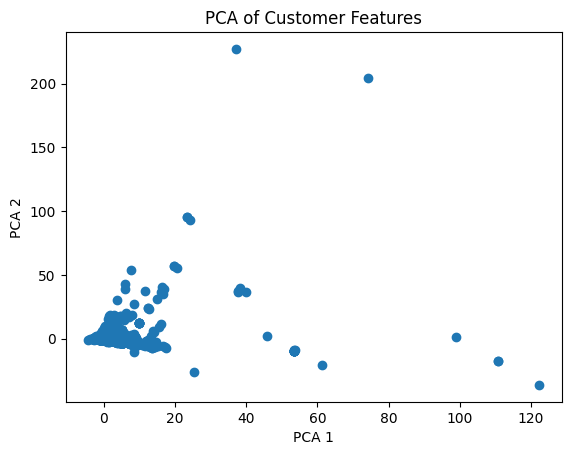

In [11]:
# PCA analysis
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA of Customer Features')
plt.show()


In [8]:
# how many of varicance is explained by each component
explained_variance = pca.explained_variance_ratio_

print(f'Explained variance by each component: {explained_variance}')

Explained variance by each component: [0.98335487]


In [14]:
# print top 5 components of PCA1 and PCA2 with labels
top_5_pca1 = pca.components_[0][:5]
top_5_pca2 = pca.components_[1][:5]
print(f'Top 5 PCA 1 components: {top_5_pca1}')
print(f'Top 5 PCA 2 components: {top_5_pca2}')


Top 5 PCA 1 components: [0.05918548 0.09655157 0.09595383 0.09637348 0.06669938]
Top 5 PCA 2 components: [-0.12222951  0.41741036  0.41635107  0.41744319 -0.07069154]


In [29]:
# Baseline K-Means on standardized features (Euclidean distance)
# Track both inertia (elbow criterion) and silhouette for k selection.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertias = []
silhouette_scores = []

best_k = None
best_silhouette = -1.0
best_kmeans = None

for n_clusters in k_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette_avg = silhouette_score(X_scaled, labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette_avg)

    print(f'k={n_clusters:2d} | inertia={inertia:,.2f} | silhouette={silhouette_avg:.4f}')

    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_k = n_clusters
        best_kmeans = kmeans

print(f'Best k by silhouette: {best_k} (score={best_silhouette:.4f})')

k= 2 | inertia=1,612,460.67 | silhouette=0.4208
k= 3 | inertia=1,501,891.52 | silhouette=0.5546
k= 4 | inertia=1,429,933.52 | silhouette=0.1074
k= 5 | inertia=1,344,539.94 | silhouette=0.1351
k= 6 | inertia=1,301,655.07 | silhouette=0.0958
k= 7 | inertia=1,198,431.81 | silhouette=0.0979
k= 8 | inertia=1,158,370.78 | silhouette=0.0984
k= 9 | inertia=1,125,577.54 | silhouette=0.1003
k=10 | inertia=1,093,488.87 | silhouette=0.0995
Best k by silhouette: 3 (score=0.5546)


Text(0.5, 1.0, 'Silhouette Scores for K-Means Clustering')

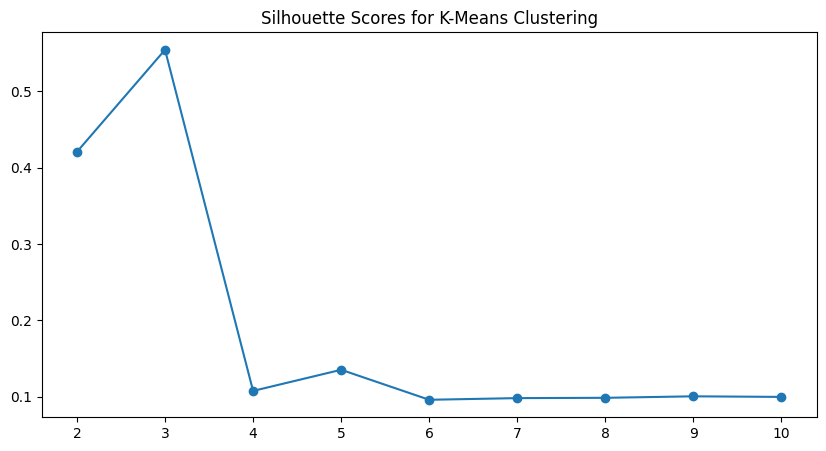

In [30]:
# plot silhouette scores for k values
plt.figure(figsize=(10, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Scores for K-Means Clustering')


In [31]:
# Cosine-oriented K-Means: normalize vectors to unit length first.
# K-Means itself is Euclidean, but on unit vectors Euclidean distance aligns with cosine similarity ranking.
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X_normalized = normalizer.fit_transform(X_scaled)

k_values_cosine = range(2, 11)
silhouette_scores_cosine = []

best_k_cosine = None
best_silhouette_cosine = -1.0
best_kmeans_cosine = None

for n_clusters in k_values_cosine:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_normalized)
    silhouette_avg = silhouette_score(X_normalized, labels, metric='cosine')
    silhouette_scores_cosine.append(silhouette_avg)

    print(f'k={n_clusters:2d} | cosine silhouette={silhouette_avg:.4f}')

    if silhouette_avg > best_silhouette_cosine:
        best_silhouette_cosine = silhouette_avg
        best_k_cosine = n_clusters
        best_kmeans_cosine = kmeans

print(f'Best k by cosine silhouette: {best_k_cosine} (score={best_silhouette_cosine:.4f})')

k= 2 | cosine silhouette=0.1369
k= 3 | cosine silhouette=0.1357
k= 4 | cosine silhouette=0.1609
k= 5 | cosine silhouette=0.1595
k= 6 | cosine silhouette=0.1592
k= 7 | cosine silhouette=0.1599
k= 8 | cosine silhouette=0.1638
k= 9 | cosine silhouette=0.1605
k=10 | cosine silhouette=0.1629
Best k by cosine silhouette: 8 (score=0.1638)


## Cosine KMeans baseline (not selected)

This experiment used unit-normalized features with KMeans and cosine silhouette scoring.
Observed silhouette performance was materially worse than the Euclidean KMeans baseline on standardized features.
Given current results, this path is retained for reference only and excluded from downstream segmentation and profiling

## DBSCAN Baseline: Why A Large Noise Count Can Happen

DBSCAN marks a point as noise (`-1`) when it has fewer than `min_samples` neighbors within radius `eps`.  
In high-dimensional feature spaces, pairwise distances tend to concentrate, so a small `eps` can leave most points without enough neighbors. This often leads to many (or nearly all) points being labeled as noise.

For this reason, DBSCAN is highly sensitive to `eps` and `min_samples`, and these parameters should be tuned (for example, with a k-distance plot) rather than fixed arbitrarily.

### References

- scikit-learn User Guide: DBSCAN and parameter sensitivity  
  https://scikit-learn.org/stable/modules/clustering.html#dbscan
- Ester, M., Kriegel, H.-P., Sander, J., Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*.
- Schubert, E., Sander, J., Ester, M., Kriegel, H.-P., Xu, X. (2017). *DBSCAN Revisited, Revisited: Why and How You Should (Still) Use DBSCAN*.

In [ ]:
# DBSCAN baseline on standardized features (Euclidean distance)
from sklearn.cluster import DBSCAN
import numpy as np

def run_dbscan(data, eps, min_samples=5, metric='euclidean'):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    labels = dbscan.fit_predict(data)
    # Count DBSCAN clusters and noise points
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    num_noise_points = (labels == -1).sum()
    return labels, num_clusters, num_noise_points, dbscan

In [41]:
# typical Euclidean distances are often around sqrt(n_features)
eps = np.sqrt(X_scaled.shape[1])

labels, num_clusters, num_noise_points, dbscan = run_dbscan(
    X_scaled, eps=eps, min_samples=5, metric="euclidean"
)

print("DBSCAN with euclidean distance:")
print(f"Number of clusters found by DBSCAN: {num_clusters}")
print(f"Number of noise points: {num_noise_points}")
# NOTE: eps and min_samples are sensitive; tune with a k-distance plot later.
# dbscan = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
# dbscan_labels = dbscan.fit_predict(X_scaled)
# dbscan_labels

Number of clusters found by DBSCAN: 13
Number of noise points: 89


In [36]:
# Count DBSCAN clusters and noise points
#num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
#num_noise_points = (dbscan_labels == -1).sum()


Number of clusters found by DBSCAN: 13
Number of noise points: 89


## Why Noise-Point Counting Matters

In density-based clustering, the number of noise points is not a side metric; it is a key diagnostic for whether DBSCAN is operating at a useful density threshold.

A very high noise count can indicate overly strict parameters, while a very low count can indicate an overly permissive neighborhood definition. Tracking this value helps us tune `eps` and `min_samples` with purpose.

For this project, these noise points are especially important: they represent customers whose purchasing behavior does not conform to dense, common patterns. Identifying and characterizing these atypical customers is a core objective of the research.

In [42]:
# Silhouette score for DBSCAN (computed only when valid)
from sklearn.metrics import silhouette_score

cluster_labels = labels[labels != -1]
if num_clusters < 2:
    print('Silhouette score not defined: fewer than 2 clusters were found.')
elif len(cluster_labels) < 2:
    print('Silhouette score not defined: not enough non-noise samples.')
else:
    non_noise_mask = labels != -1
    silhouette_avg = silhouette_score(X_scaled[non_noise_mask], labels[non_noise_mask])
    print(f'Silhouette score for DBSCAN (excluding noise): {silhouette_avg:.4f}')

Silhouette score for DBSCAN (excluding noise): 0.4831


=======================================================================================

find eps for cosine similarity

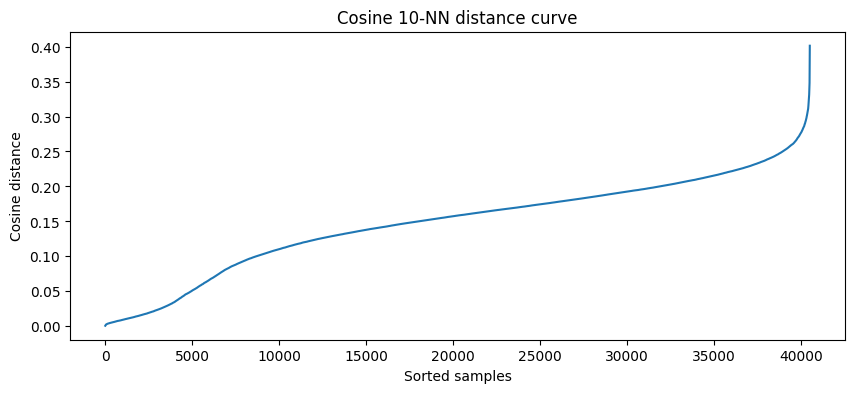

Initial eps guess: 0.2433


In [46]:
# 2) choose min_samples
from sklearn.neighbors import NearestNeighbors


min_samples = 10

nn = NearestNeighbors(n_neighbors=min_samples, metric='cosine')
nn.fit(X_normalized)
distances, _ = nn.kneighbors(X_normalized)

kdist = np.sort(distances[:, -1])  # distance to k-th neighbor

# plot knee
plt.figure(figsize=(10, 4))
plt.plot(kdist)
plt.title(f'Cosine {min_samples}-NN distance curve')
plt.xlabel('Sorted samples')
plt.ylabel('Cosine distance')
plt.show()

# 4) starting eps guess: high quantile if knee is hard to see
eps_cosine = float(np.quantile(kdist, 0.95))
print(f"Initial eps guess: {eps_cosine:.4f}")


In [47]:
labels, num_clusters, num_noise_points, dbscan = run_dbscan(
    X_normalized, eps=eps_cosine, min_samples=5, metric="cosine"
)

print("DBSCAN with cosine distance:")
print(f"Number of clusters found by DBSCAN: {num_clusters}")
print(f"Number of noise points: {num_noise_points}")

DBSCAN with cosine distance:
Number of clusters found by DBSCAN: 3
Number of noise points: 64


This is a very promising result: small number clusters, and small number of noise point. 
We will evaluate stability and robustness of the best cluster so far: DBSCAN with cosine similarity.

This what will be checked:
- small changes in eps and min_samples yields similar results
- 3 clusters are interpretable
- 64 customers outside of any clusters are truly "out of line", not just some data error.

If we satisfied with results, no further clustering algorithms will be evaluated - it will not get us closer to the the research question.